In [499]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo/tools')
import os
import glob

In [500]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [501]:
import sys
sys.path.append('/home/jovyan/work/base_demo')
import base_tool

In [502]:
import pandas as pd
import numpy as np
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 65)

数据介绍

bid_book_begin 集合竞价后的完整委托买入订单簿

ask_book_begin 集合竞价后的完整委托卖出订单簿

snap_list 连续竞价阶段的1s快照
    time_hms  时分秒字符串
    time_mark 毫秒级时间戳
    price_open 快照内首个成交价(无成交时为0.0)
    price_low  快照内最低成交价(无成交时为0.0)
    price_high 快照内最高成交价(无成交时为0.0)
    price_last 当日内最新成交价
     buy_trade 主动买入成交
    sell_trade 主动卖出成交
    bid_insert 委托买入挂单
    ask_insert 委托卖出挂单
    bid_cancel 委托买入撤单
    ask_cancel 委托卖出撤单

In [503]:
import numpy as np
import pandas as pd

class TrainValidTest():
    def __init__(self, snap_list, param_dict,feature_func,y_func):
        if param_dict is not None:
            self.__dict__.update(param_dict)
        # 确保必要属性存在
        if not hasattr(self, 'x_window'):
            self.x_window = 1
        if not hasattr(self, 'y_window'):
            self.y_window = 1

        self.snap_list = snap_list.copy()
        self.create_feature = feature_func
        self.create_y = y_func

    def samples(self):
        X_list, y_list = [], []
        n = len(self.snap_list)
        stride = getattr(self, 'stride', 1)

        for i in range(self.x_window, n - self.y_window, stride):
            x = self.create_feature(self.snap_list[i - self.x_window:i])
            volatility = x['volatility'].iloc[0] if 'volatility' in x.columns else 0.0
            y = self.create_y(self.snap_list[i:i + self.y_window], volatility, self.k_up, self.k_down)
            X_list.append(x)
            y_list.append(y)

        X_all = pd.concat(X_list, axis=0, ignore_index=True)
        y_all = pd.concat(y_list, axis=0, ignore_index=True)

        return X_all, y_all

def samples_from_dates(dates, instrument_id, param_dict, create_feature, create_y):
    X_all_list = []
    y_all_list = []
    
    for date in dates:
        try:
            snap_list = base_tool.snap_list_load(instrument_id, date)
            if len(snap_list) < param_dict['x_window'] + param_dict['y_window']:
                print(f"{date}: 数据不足，跳过")
                continue
            tv = TrainValidTest(snap_list, param_dict, create_feature, create_y)
            X_day, y_day = tv.samples()
            X_all_list.append(X_day)
            y_all_list.append(y_day)
            print(f"{date}: 产生 {len(X_day)} 个样本")
        except Exception as e:
            print(f"{date}: 加载失败 - {e}")
    
    if X_all_list:
        X_total = pd.concat(X_all_list, axis=0, ignore_index=True)
        y_total = pd.concat(y_all_list, axis=0, ignore_index=True)
    else:
        X_total = pd.DataFrame()
        y_total = pd.Series()
    
    return X_total, y_total

def create_y(snap_slice, volatility, k_up, k_down):
    # 初始化突破时间索引为 None
    t_up = None
    t_down = None

    start = snap_slice[0]['price_last']
    if start is None or start == 0 or pd.isna(start):
        return pd.Series([0])

    up = start * (1 + volatility * k_up)
    down = start * (1 - volatility * k_down)

    for i in range(1, len(snap_slice)):
        price = snap_slice[i]['price_last']
        if price is None or pd.isna(price):
            continue

        if t_up is None and price >= up:
            t_up = i
        if t_down is None and price <= down:
            t_down = i

        if t_up is not None and t_down is not None:
            break

    # 根据触发情况决定标签
    if t_up is not None and t_down is not None:
        label = 1 if t_up < t_down else -1
    elif t_up is not None:
        label = 1
    elif t_down is not None:
        label = -1
    else:
        label = 0

    return pd.Series([label])

def create_feature(snap_slice):
    """
    从特征窗口快照切片中提取特征，并计算波动率。
    """
    last = snap_slice[-1]

    price = last['price_last']
    trades = last['num_trades']
    best_bid = last['bid_book'][0][0] if last['bid_book'] is not None and len(last['bid_book']) > 0 else np.nan
    best_ask = last['ask_book'][0][0] if last['ask_book'] is not None and len(last['ask_book']) > 0 else np.nan
    bid_depth = last['bid_book'][0][1] if last['bid_book'] is not None and len(last['bid_book']) > 0 else 0
    ask_depth = last['ask_book'][0][1] if last['ask_book'] is not None and len(last['ask_book']) > 0 else 0
    spread = best_ask - best_bid if not np.isnan(best_ask) and not np.isnan(best_bid) else np.nan


    # 基于特征窗口内的价格序列计算波动率（相对波动率 = 标准差 / 均值）
    prices = [snap['price_last'] for snap in snap_slice if snap['price_last'] is not None]
    if len(prices) >= 2:
        mean_price = np.mean(prices)
        std_price = np.std(prices)
        volatility = std_price / mean_price if mean_price != 0 else 0.0
    else:
        volatility = 0.0

    features = {
        'price_last': price,
        'num_trades': trades,
        'best_bid': best_bid,
        'best_ask': best_ask,
        'spread': spread,
        'bid_depth1': bid_depth,
        'ask_depth1': ask_depth,
        'volatility': volatility,
    }
    return pd.DataFrame([features])

## XGBoost 模型训练

In [504]:
import xgboost as xgb
import joblib
from sklearn.metrics import accuracy_score, classification_report

instrument_id = '511520'
train_days = 20
valid_days = 4
test_days = 5

trade_dates = ['20260202', '20260203', '20260204', '20260205', '20260206',
                '20260209', '20260210', '20260211', '20260212', '20260213',
                '20260224', '20260225', '20260226', '20260227', '20260302',
                '20260303', '20260304', '20260305', '20260306', '20260309',
                '20260310', '20260311', '20260312', '20260313', '20260316',
                '20260317', '20260318', '20260319', '20260320']
print(f"总交易日数量: {len(trade_dates)}")
print(f"交易日范围: {trade_dates[0]} ~ {trade_dates[-1]}")

总交易日数量: 29
交易日范围: 20260202 ~ 20260320


In [505]:
train_dates = trade_dates[:train_days]
valid_dates = trade_dates[train_days:train_days + valid_days]
test_dates = trade_dates[train_days + valid_days:train_days + valid_days + test_days]

print(f"训练集: {train_dates[0]} ~ {train_dates[-1]} ({len(train_dates)}天)")
print(f"验证集: {valid_dates[0]} ~ {valid_dates[-1]} ({len(valid_dates)}天)")
print(f"测试集: {test_dates[0]} ~ {test_dates[-1]} ({len(test_dates)}天)")

训练集: 20260202 ~ 20260309 (20天)
验证集: 20260310 ~ 20260313 (4天)
测试集: 20260316 ~ 20260320 (5天)


In [522]:
%%time
instrument_id = '511520'
trade_ymd = '20260319'
param_dict = {

    'name' : 'TBM',
    'instrument_id' : instrument_id,
    'trade_ymd' : trade_ymd,
    
    'x_window' : 300 ,
    'y_window' : 300 ,
    'stride': 60,

    'k_up': 3,
    'k_down': 3
}

print("生成训练集样本...")
X_train, y_train = samples_from_dates(train_dates, instrument_id, param_dict, create_feature, create_y)
print(f"训练集样本: X={X_train.shape}, y={y_train.shape}")
if len(y_train) > 0:
    print(f"标签分布:\n{y_train.value_counts()}")

生成训练集样本...
20260202: 产生 231 个样本
20260203: 产生 231 个样本
20260204: 产生 231 个样本
20260205: 产生 231 个样本
20260206: 产生 231 个样本
20260209: 产生 231 个样本
20260210: 产生 231 个样本
20260211: 产生 231 个样本
20260212: 产生 231 个样本
20260213: 产生 231 个样本
20260224: 产生 231 个样本
20260225: 产生 231 个样本
20260226: 产生 231 个样本
20260227: 产生 231 个样本
20260302: 产生 231 个样本
20260303: 产生 231 个样本
20260304: 产生 231 个样本
20260305: 产生 231 个样本
20260306: 产生 231 个样本
20260309: 产生 231 个样本
训练集样本: X=(4620, 8), y=(4620,)
标签分布:
 0    2179
 1    1266
-1    1175
Name: count, dtype: int64
CPU times: user 5.27 s, sys: 37 ms, total: 5.3 s
Wall time: 5.3 s


In [523]:
%%time
print("生成验证集样本...")
X_valid, y_valid = samples_from_dates(valid_dates, instrument_id, param_dict, create_feature, create_y)
print(f"验证集样本: X={X_valid.shape}, y={y_valid.shape}")
if len(y_valid) > 0:
    print(f"标签分布:\n{y_valid.value_counts()}")

生成验证集样本...
20260310: 产生 231 个样本
20260311: 产生 231 个样本
20260312: 产生 231 个样本
20260313: 产生 231 个样本
验证集样本: X=(924, 8), y=(924,)
标签分布:
 0    456
 1    248
-1    220
Name: count, dtype: int64
CPU times: user 896 ms, sys: 3 ms, total: 899 ms
Wall time: 898 ms


In [524]:
from sklearn.preprocessing import LabelEncoder

y_train_flat = y_train.values.ravel() if hasattr(y_train, 'values') else y_train.ravel()
y_valid_flat = y_valid.values.ravel() if hasattr(y_valid, 'values') else y_valid.ravel()

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_flat)
y_valid_encoded = le.transform(y_valid_flat)
print(f"标签编码: {le.classes_} -> [0, 1, 2]")
print(f"编码后训练集标签分布: {pd.Series(y_train_encoded).value_counts().sort_index().to_dict()}")

标签编码: [-1  0  1] -> [0, 1, 2]
编码后训练集标签分布: {0: 1175, 1: 2179, 2: 1266}


In [525]:
%%time
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    n_jobs=-1,
    verbosity=1
)

model.fit(
    X_train, y_train_encoded,
    eval_set=[(X_valid, y_valid_encoded)],
    verbose=10
)

[0]	validation_0-mlogloss:1.04328
[10]	validation_0-mlogloss:1.03265
[20]	validation_0-mlogloss:1.02405


[30]	validation_0-mlogloss:1.01776
[40]	validation_0-mlogloss:1.00980
[50]	validation_0-mlogloss:1.00451
[60]	validation_0-mlogloss:0.99947
[70]	validation_0-mlogloss:0.99593
[80]	validation_0-mlogloss:0.99225
[90]	validation_0-mlogloss:0.98846
[100]	validation_0-mlogloss:0.98491
[110]	validation_0-mlogloss:0.98240
[120]	validation_0-mlogloss:0.98024
[130]	validation_0-mlogloss:0.97727
[140]	validation_0-mlogloss:0.97491
[150]	validation_0-mlogloss:0.97319
[160]	validation_0-mlogloss:0.97159
[170]	validation_0-mlogloss:0.97057
[180]	validation_0-mlogloss:0.96928
[190]	validation_0-mlogloss:0.96786
[199]	validation_0-mlogloss:0.96700
CPU times: user 7.7 s, sys: 21 ms, total: 7.73 s
Wall time: 251 ms


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [526]:
y_pred_encoded = model.predict(X_valid)
y_pred = le.inverse_transform(y_pred_encoded)
print("验证集准确率:", accuracy_score(y_valid, y_pred))

unique_labels = sorted(set(y_valid.unique()) | set(np.unique(y_pred)))
label_names = { -1: '下跌(-1)', 0: '持平(0)', 1: '上涨(1)' }
target_names = [label_names.get(l, str(l)) for l in unique_labels]
print("分类报告:")
print(classification_report(y_valid, y_pred, labels=unique_labels, target_names=target_names))

验证集准确率: 0.5487012987012987
分类报告:
              precision    recall  f1-score   support

      下跌(-1)       0.42      0.18      0.25       220
       持平(0)       0.58      0.89      0.70       456
       上涨(1)       0.47      0.25      0.32       248

    accuracy                           0.55       924
   macro avg       0.49      0.44      0.43       924
weighted avg       0.51      0.55      0.49       924



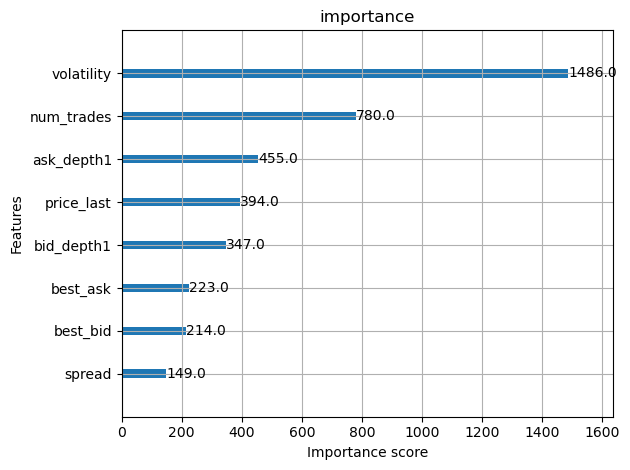

In [527]:
import matplotlib.pyplot as plt
xgb.plot_importance(model, max_num_features=10)
plt.title('importance')
plt.tight_layout()
plt.show()

In [528]:
model_path = f'/home/jovyan/work/backtest_result/{instrument_id}_xgb_model.pkl'
le_path = f'/home/jovyan/work/backtest_result/{instrument_id}_label_encoder.pkl'
joblib.dump(model, model_path)
joblib.dump(le, le_path)
print(f"模型已保存至: {model_path}")
print(f"标签编码器已保存至: {le_path}")

模型已保存至: /home/jovyan/work/backtest_result/511520_xgb_model.pkl
标签编码器已保存至: /home/jovyan/work/backtest_result/511520_label_encoder.pkl


## 测试集预测

In [529]:
%%time
print("生成测试集样本...")
X_test, y_test = samples_from_dates(test_dates, instrument_id, param_dict, create_feature, create_y)
print(f"测试集样本: X={X_test.shape}, y={y_test.shape}")

生成测试集样本...
20260316: 产生 231 个样本
20260317: 产生 231 个样本
20260318: 产生 231 个样本
20260319: 产生 231 个样本
20260320: 产生 231 个样本
测试集样本: X=(1155, 8), y=(1155,)
CPU times: user 1.06 s, sys: 9 ms, total: 1.07 s
Wall time: 1.07 s


In [530]:
y_test_flat = y_test.values.ravel() if hasattr(y_test, 'values') else y_test.ravel()
y_test_encoded = le.transform(y_test_flat)
y_test_pred_encoded = model.predict(X_test)
y_test_pred = le.inverse_transform(y_test_pred_encoded)
print("测试集准确率:", accuracy_score(y_test_flat, y_test_pred))
print("\n分类报告:")
print(classification_report(y_test_flat, y_test_pred, target_names=['下跌(-1)', '持平(0)', '上涨(1)']))

测试集准确率: 0.5523809523809524

分类报告:
              precision    recall  f1-score   support

      下跌(-1)       0.36      0.27      0.31       270
       持平(0)       0.64      0.86      0.73       537
       上涨(1)       0.44      0.30      0.36       348

    accuracy                           0.55      1155
   macro avg       0.48      0.48      0.47      1155
weighted avg       0.52      0.55      0.52      1155



## 基于模型的回测

In [515]:
class StrategyDemo():
    def __init__(self, model, param_dict={}) -> None:
        self.__dict__.update(param_dict)
        self.model = model
        self.feature_buffer = []
        self.position_last = 0
        self.prev_signal = 0
        
        data_file = f'/home/jovyan/work/backtest_result/{self.instrument_id}_{self.trade_ymd}_{self.name}_xgb.pkl'
        if os.path.exists(data_file):
            os.remove(data_file)

    def on_snap(self, snap:dict) -> None:
        price = snap['price_last']
        
        if price == 0.0 or price == None:
            return
        
        self.feature_buffer.append(snap)
        
        if len(self.feature_buffer) < self.x_window:
            self.position_last = 0
            self.prev_signal = 0
            return
        
        if len(self.feature_buffer) > self.x_window:
            self.feature_buffer.pop(0)
        
        features = create_feature(self.feature_buffer[-self.x_window:])
        X_pred = features.values.reshape(1, -1)
        
        try:
            prediction = self.model.predict(X_pred)[0]
            if prediction != self.prev_signal:
                self.position_last = int(prediction)
                self.prev_signal = int(prediction)
        except Exception as e:
            pass
        return

In [516]:
import os
import sys
current_notebook_path = os.path.abspath('%pwd') 
current_dir = os.path.dirname(current_notebook_path)
parent_dir = os.path.dirname(current_dir)
utils_path = os.path.join(parent_dir, 'tools')
sys.path.append(utils_path)

In [517]:
from backtesting import backtest_multi_days
param_dict['trade_ymd'] = ''
strategy = StrategyDemo(model,param_dict)
backtest_df = backtest_multi_days(instrument_id,'20260316','20260320',strategy,param_dict)

/home/jovyan/work/backtest_result/511520_20260316_TBM.pkl 生成中
日期 20260316 回测完成，当日盈亏: -15.60
/home/jovyan/work/backtest_result/511520_20260317_TBM.pkl 生成中
日期 20260317 回测完成，当日盈亏: -27.90
/home/jovyan/work/backtest_result/511520_20260318_TBM.pkl 生成中
日期 20260318 回测完成，当日盈亏: -21.80
/home/jovyan/work/backtest_result/511520_20260319_TBM.pkl 生成中
日期 20260319 回测完成，当日盈亏: -17.40
/home/jovyan/work/backtest_result/511520_20260320_TBM.pkl 生成中
日期 20260320 回测完成，当日盈亏: -65.20


In [518]:
backtest_df

,trade_ymd,order_time,order_price,total,trade,cancel,hold,profit_last,profits,maxdd,MAR,pper
0,20260316,2026-03-16 14:55:00,115.794,233,226,7,0,0.6,-15.6,16.2,-0.96,-0.07
1,20260317,2026-03-17 14:55:00,115.895,430,420,10,0,-0.1,-27.9,28.2,-0.99,-0.07
2,20260318,2026-03-18 14:55:00,116.027,456,444,12,0,-1.0,-21.8,24.5,-0.89,-0.05
3,20260319,2026-03-19 14:55:00,116.169,251,246,5,0,-0.3,-17.4,24.3,-0.72,-0.07
4,20260320,2026-03-20 14:55:00,116.062,613,598,15,0,-0.1,-65.2,65.2,-1.00,-0.11


In [519]:
from backtesting import backtest_summary
summary = backtest_summary(backtest_df)
print(summary)

{'交易天数': 5, '累计盈亏': np.float64(-147.9), '最大单日盈利': -15.6, '最大单日亏损': -65.2, '盈利天数': 0, '亏损天数': 5, '平盘天数': 0, '胜率(%)': np.float64(0.0), '日均盈亏': np.float64(-29.58), '盈亏比': np.float64(0.0)}
